# KV cache benchmark harness

Measures decoding speed and memory for the `vanilla=True` (no cache, recomputes
full context every step) vs `vanilla=False` (KV cache) paths in `mingpt/model.py`,
following the harness spec in `CLAUDE.md`.

**Order matters**: this harness is written and validated *before* any new
generation method (speculative decoding) is added, and it is run against the
already-fixed `generate` as the baseline. Do not use this notebook's numbers if
the `attn_vanilla` double-compute bug is still present in `model.py` — every
timing here silently doubles otherwise.

**Device note**: this machine has `torch==2.6.0+cpu`, no CUDA. All the
`torch.cuda.*` calls below are gated behind a device check so the harness runs
here for correctness/debugging, but the CPU numbers are **not** the thesis
numbers — VRAM metrics are `None` on CPU, and CPU wall-clock timing has much
higher relative noise than a quiet GPU. Re-run this notebook on Colab (GPU) to
produce the numbers that actually go in the thesis; only the harness logic is
being validated locally.


In [1]:
import json
import math
import platform
import time
from pathlib import Path

import torch

from mingpt.model import GPT
from mingpt.utils import set_seed

SEED = 3407
set_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def device_name():
    if DEVICE == 'cuda':
        return torch.cuda.get_device_name()
    return f"CPU: {platform.processor() or platform.machine()}"

print(f"device        = {DEVICE}")
print(f"device_name   = {device_name()}")
print(f"torch version = {torch.__version__}")


device        = cpu
device_name   = CPU: Intel64 Family 6 Model 154 Stepping 3, GenuineIntel
torch version = 2.6.0+cpu


## Timing / memory primitives

`torch.cuda.synchronize()` and `torch.cuda.reset_peak_memory_stats()` are only
meaningful (and only defined without error) on CUDA — these wrappers make them
no-ops on CPU instead of the harness crashing outright.


In [2]:
def device_sync():
    if DEVICE == 'cuda':
        torch.cuda.synchronize()

def reset_peak_memory():
    if DEVICE == 'cuda':
        torch.cuda.reset_peak_memory_stats()

def peak_memory_bytes():
    if DEVICE == 'cuda':
        return torch.cuda.max_memory_allocated()
    return None  # not tracked on CPU; see device note above


## KV cache memory: analytical vs measured

Analytical formula from `CLAUDE.md`: `2 * B * L * n_embd * T * bytes_per_element`
(the factor 2 is K and V; `n_embd` already sums over all heads since
`n_embd = n_head * head_size`).


In [3]:
def analytical_kv_cache_bytes(batch, n_layer, n_embd, seq_len, dtype=torch.float32):
    return 2 * batch * n_layer * n_embd * seq_len * torch.tensor([], dtype=dtype).element_size()

def measured_kv_cache_bytes(model):
    total = 0
    for block in model.transformer.h:
        k = getattr(block.attn, 'k_cache', None)
        v = getattr(block.attn, 'v_cache', None)
        if k is not None:
            total += k.numel() * k.element_size()
        if v is not None:
            total += v.numel() * v.element_size()
    return total


## Core measurement

One call = one full timed generation, split into TTFT (prefill) and total time,
so `TPOT = (total_time - TTFT) / (generated_tokens - 1)` per the metric table.

TTFT is measured with a dedicated prefill-only forward pass (`model(idx_cond,
False)`), *not* by instrumenting `generate()` — this keeps `generate()`
untouched as the correctness reference and works identically for `vanilla=True`
and `vanilla=False` models, since the `kv_cached` flag on `forward` only
controls the position-embedding offset (see `model.py` `forward`). The cache
is reset before and after the probe so it doesn't contaminate the timed
`generate()` call that follows.


In [4]:
@torch.no_grad()
def run_once(model, idx, max_new_tokens, do_sample=False, top_k=None, temperature=1.0):
    idx_cond = idx if idx.size(1) <= model.block_size else idx[:, -model.block_size:]

    # --- TTFT: dedicated prefill-only forward pass ---
    if not model.vanilla:
        model.reset_kv_cache()
    device_sync()
    t0 = time.perf_counter()
    model(idx_cond, kv_cached=False)
    device_sync()
    t1 = time.perf_counter()
    ttft = t1 - t0
    if not model.vanilla:
        model.reset_kv_cache()

    # --- full generation, timed as a whole ---
    reset_peak_memory()
    device_sync()
    t2 = time.perf_counter()
    out = model.generate(idx, max_new_tokens=max_new_tokens, do_sample=do_sample,
                          top_k=top_k, temperature=temperature)
    device_sync()
    t3 = time.perf_counter()
    total_time = t3 - t2

    generated_tokens = max_new_tokens
    tpot = (total_time - ttft) / (generated_tokens - 1) if generated_tokens > 1 else float('nan')
    throughput = generated_tokens / total_time

    kv_measured = measured_kv_cache_bytes(model) if not model.vanilla else 0
    # Cached generate() maintains T_cache = T_output - 1: the last generated token was
    # never itself passed through a forward pass, so it isn't in the cache yet. Using
    # out.size(1) here would systematically overstate the analytical figure by exactly
    # one token's worth of KV bytes vs. what's actually measured. See
    # prompt_prefinal_fixes.md, P0-2. (Vanilla has no cache; seq_len there is informational
    # only, not compared against a measured value anywhere downstream.)
    if not model.vanilla:
        seq_len = model.transformer.h[0].attn.k_cache.size(2)
        kv_dtype = model.transformer.h[0].attn.k_cache.dtype
    else:
        seq_len = out.size(1)
        kv_dtype = torch.float32
    kv_analytical = analytical_kv_cache_bytes(out.size(0), model.num_layers,
                                               model.transformer.wte.embedding_dim, seq_len,
                                               dtype=kv_dtype)

    return {
        'ttft': ttft,
        'total_time': total_time,
        'tpot': tpot,
        'throughput': throughput,
        'peak_memory_bytes': peak_memory_bytes(),
        'kv_cache_measured_bytes': kv_measured,
        'kv_cache_analytical_bytes': kv_analytical,
        'seq_len': seq_len,
        'out': out,
    }


## Benchmark harness: warmup + N=5 repeats, median/range

Per spec: 3 warmup iterations (untimed, just to settle allocator/caches), then
N=5 timed repeats, reporting median and (min, max) range rather than only the
mean.


In [5]:
def _median(xs):
    xs = sorted(xs)
    n = len(xs)
    mid = n // 2
    if n % 2 == 1:
        return xs[mid]
    return (xs[mid - 1] + xs[mid]) / 2

def summarize(values):
    values = [v for v in values if v is not None]
    if not values:
        return {'median': None, 'min': None, 'max': None}
    return {'median': _median(values), 'min': min(values), 'max': max(values)}

def benchmark_config(model, idx, max_new_tokens, n_warmup=3, n_reps=5, **gen_kwargs):
    for _ in range(n_warmup):
        run_once(model, idx, max_new_tokens, **gen_kwargs)

    metrics = ['ttft', 'total_time', 'tpot', 'throughput', 'peak_memory_bytes',
               'kv_cache_measured_bytes', 'kv_cache_analytical_bytes']
    raw = {m: [] for m in metrics}
    for _ in range(n_reps):
        result = run_once(model, idx, max_new_tokens, **gen_kwargs)
        for m in metrics:
            raw[m].append(result[m])

    return {
        'n_warmup': n_warmup,
        'n_reps': n_reps,
        'prompt_len': idx.size(1),
        'max_new_tokens': max_new_tokens,
        'raw': raw,
        'summary': {m: summarize(raw[m]) for m in metrics},
    }


## Result persistence (JSON + metadata)

Locally this writes under `./bench_results/`. **On Colab**, mount Drive first
and point `RESULTS_DIR` at it, e.g.
`RESULTS_DIR = Path('/content/drive/MyDrive/thesis/bench_results')`, so raw
results survive session resets.


In [6]:
# On Colab, write straight to Google Drive so results survive a runtime
# disconnect/recycle instead of living only on the ephemeral VM disk -- per
# CLAUDE.md's harness spec ("raw results in JSON, written to Google Drive").
# Locally (no google.colab module), falls back to a plain relative folder.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    RESULTS_DIR = Path('/content/drive/MyDrive/mingpt_bench_results')
except ImportError:
    RESULTS_DIR = Path('bench_results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'writing results to: {RESULTS_DIR.resolve()}')

def save_result(name, model_type, cached, benchmark_result):
    payload = {
        'metadata': {
            'gpu_type': device_name(),
            'device': DEVICE,
            'torch_version': torch.__version__,
            'seed': SEED,
            'model_type': model_type,
            'cached': cached,
            'prompt_len': benchmark_result['prompt_len'],
            'max_new_tokens': benchmark_result['max_new_tokens'],
        },
        'summary': benchmark_result['summary'],
        'raw': benchmark_result['raw'],
    }
    path = RESULTS_DIR / f"{name}.json"
    with open(path, 'w') as f:
        json.dump(payload, f, indent=2)
    return path


writing results to: C:\Users\Aleksa\Desktop\MinGPT\minGPT-fresh\bench_results


## Smoke test

Confirms the harness runs end-to-end and produces sane numbers. Uses
`gpt-nano` with tiny rep counts so this executes in seconds on CPU — **not**
a real measurement, just a pipeline check. Delete/skip this cell's assertions
once you trust the harness; keep re-running it after any change to
`run_once`/`benchmark_config`.


In [7]:
def make_toy_config(model_type='gpt-nano', vocab_size=100, block_size=64):
    config = GPT.get_default_config()
    config.model_type = model_type
    config.vocab_size = vocab_size
    config.block_size = block_size
    return config

set_seed(1234)
toy_cached = GPT(make_toy_config(), vanilla=False).to(DEVICE).eval()
set_seed(1234)
toy_baseline = GPT(make_toy_config(), vanilla=True).to(DEVICE).eval()

toy_prompt = torch.randint(0, 100, (1, 8), device=DEVICE)

smoke_cached = benchmark_config(toy_cached, toy_prompt, max_new_tokens=10, n_warmup=1, n_reps=2)
smoke_baseline = benchmark_config(toy_baseline, toy_prompt, max_new_tokens=10, n_warmup=1, n_reps=2)

assert smoke_cached['summary']['tpot']['median'] is not None
assert smoke_baseline['summary']['tpot']['median'] is not None
assert smoke_cached['summary']['kv_cache_measured_bytes']['median'] > 0
assert smoke_baseline['summary']['kv_cache_measured_bytes']['median'] == 0

print('cached   TPOT median (s):', smoke_cached['summary']['tpot']['median'])
print('baseline TPOT median (s):', smoke_baseline['summary']['tpot']['median'])
print('smoke test passed: harness pipeline runs end-to-end')


number of parameters: 0.09M
number of parameters: 0.09M
cached   TPOT median (s): 0.0011042444514007205
baseline TPOT median (s): 0.002010222213963668
smoke test passed: harness pipeline runs end-to-end


## Figure 1 data: TPOT vs. context length, cached vs. baseline, per model scale

Sweeps prompt length for each of two toy model scales. Swap `MODEL_TYPES` for
`['gpt2', 'gpt2-medium']` (loaded via `GPT.from_pretrained`) to get the
thesis-real sweep on Colab — that download needs network access and a GPU to
run in reasonable time, so it's left as toy models here for local validation.


In [8]:
import pandas as pd

MODEL_TYPES = ['gpt-nano', 'gpt-micro']   # swap for ['gpt2', 'gpt2-medium'] on Colab
CONTEXT_LENGTHS = [8, 16, 32]              # prompt lengths to sweep
MAX_NEW_TOKENS = 20
N_REPS = 5

sweep_rows = []
for model_type in MODEL_TYPES:
    for cached in [True, False]:
        set_seed(1234)
        model = GPT(make_toy_config(model_type=model_type), vanilla=not cached).to(DEVICE).eval()
        for prompt_len in CONTEXT_LENGTHS:
            prompt = torch.randint(0, 100, (1, prompt_len), device=DEVICE)
            result = benchmark_config(model, prompt, max_new_tokens=MAX_NEW_TOKENS, n_reps=N_REPS)
            save_result(f"{model_type}_{'cache' if cached else 'baseline'}_ctx{prompt_len}",
                        model_type, cached, result)
            sweep_rows.append({
                'model_type': model_type,
                'cached': cached,
                'prompt_len': prompt_len,
                'tpot_median': result['summary']['tpot']['median'],
                'tpot_min': result['summary']['tpot']['min'],
                'tpot_max': result['summary']['tpot']['max'],
                'peak_mem_median': result['summary']['peak_memory_bytes']['median'],
                'kv_measured_median': result['summary']['kv_cache_measured_bytes']['median'],
                'kv_analytical_median': result['summary']['kv_cache_analytical_bytes']['median'],
            })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df


number of parameters: 0.09M


number of parameters: 0.09M


number of parameters: 0.81M


number of parameters: 0.81M


,model_type,cached,prompt_len,tpot_median,tpot_min,tpot_max,peak_mem_median,kv_measured_median,kv_analytical_median
0,gpt-nano,True,8,0.001152,0.001053,0.001355,None,31104,31104
1,gpt-nano,True,16,0.001190,0.001144,0.001421,None,40320,40320
2,gpt-nano,True,32,0.003773,0.002792,0.005054,None,58752,58752
3,gpt-nano,False,8,0.003105,0.002966,0.003526,None,0,32256
4,gpt-nano,False,16,0.003297,0.003223,0.003438,None,0,41472
5,gpt-nano,False,32,0.003939,0.003607,0.004451,None,0,59904
6,gpt-micro,True,8,0.004743,0.002906,0.004867,None,110592,110592
7,gpt-micro,True,16,0.003911,0.003678,0.004134,None,143360,143360
8,gpt-micro,True,32,0.003640,0.003392,0.003897,None,208896,208896
9,gpt-micro,False,8,0.004663,0.004609,0.004730,None,0,114688


### Real model scales: `gpt2` / `gpt2-medium`

The toy sweep above isn't actually CPU-only by design -- it already runs on
whatever `DEVICE` is, via `.to(DEVICE)`. So there's no hardware confound to
worry about: run this notebook on a Colab GPU runtime and *both* the toy
sweep and this real-model sweep land on the same GPU, making the small-scale
vs. real-scale comparison in Figures 1-2 an apples-to-apples one. Locally on
CPU it's just slower, not different in kind.

One cell per model (not a shared loop) so a slow or interrupted run on one
model doesn't lose the other's results, and either can be re-run alone
without repeating the whole sweep. Uses real trained weights via
`GPT.from_pretrained`, not `make_toy_config` -- `make_toy_config` always
produces a randomly-initialized model, which would be fine for timing (cost
doesn't depend on weight values) but wrong for consistency with the
`from_pretrained` pair already used in Figures 3-5.

Context lengths go wider than the toy sweep's `[8, 16, 32]` (bounded by the
toy config's `block_size=64`) since real `gpt2`'s `block_size=1024` allows
testing further into the regime the thesis's scale-dependence claim is
actually about. `MAX_NEW_TOKENS` and `N_REPS` are reused unchanged from the
toy sweep above for direct comparability.

In [9]:
REAL_MODEL_TYPES = ['gpt2', 'gpt2-medium']
REAL_CONTEXT_LENGTHS = [32, 64, 128, 256]  # gpt2's block_size=1024 allows headroom above these

real_sweep_rows = []

In [10]:
# gpt2 (own cell: see rationale above)
model_type = 'gpt2'
for cached in [True, False]:
    model = GPT.from_pretrained(model_type, vanilla=not cached).to(DEVICE).eval()
    for prompt_len in REAL_CONTEXT_LENGTHS:
        set_seed(1234)
        vocab_size = model.transformer.wte.num_embeddings
        prompt = torch.randint(0, vocab_size, (1, prompt_len), device=DEVICE)
        result = benchmark_config(model, prompt, max_new_tokens=MAX_NEW_TOKENS, n_reps=N_REPS)
        save_result(f"{model_type}_{'cache' if cached else 'baseline'}_ctx{prompt_len}",
                    model_type, cached, result)
        real_sweep_rows.append({
            'model_type': model_type,
            'cached': cached,
            'prompt_len': prompt_len,
            'tpot_median': result['summary']['tpot']['median'],
            'tpot_min': result['summary']['tpot']['min'],
            'tpot_max': result['summary']['tpot']['max'],
            'peak_mem_median': result['summary']['peak_memory_bytes']['median'],
            'kv_measured_median': result['summary']['kv_cache_measured_bytes']['median'],
            'kv_analytical_median': result['summary']['kv_cache_analytical_bytes']['median'],
        })
    del model
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

print(f"{model_type} sweep done: "
      f"{len([r for r in real_sweep_rows if r['model_type'] == model_type])} rows")

C:\Users\Aleksa\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


number of parameters: 124.44M


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6674.16it/s]

MinGPT model has: 161 parameters
HuggingFace checkpoint has: 149 parameters
Keys to copy: 149


number of parameters: 124.44M


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 8334.77it/s]

MinGPT model has: 161 parameters
HuggingFace checkpoint has: 149 parameters
Keys to copy: 149


gpt2 sweep done: 8 rows


In [11]:
# gpt2-medium (own cell: see rationale above)
model_type = 'gpt2-medium'
for cached in [True, False]:
    model = GPT.from_pretrained(model_type, vanilla=not cached).to(DEVICE).eval()
    for prompt_len in REAL_CONTEXT_LENGTHS:
        set_seed(1234)
        vocab_size = model.transformer.wte.num_embeddings
        prompt = torch.randint(0, vocab_size, (1, prompt_len), device=DEVICE)
        result = benchmark_config(model, prompt, max_new_tokens=MAX_NEW_TOKENS, n_reps=N_REPS)
        save_result(f"{model_type}_{'cache' if cached else 'baseline'}_ctx{prompt_len}",
                    model_type, cached, result)
        real_sweep_rows.append({
            'model_type': model_type,
            'cached': cached,
            'prompt_len': prompt_len,
            'tpot_median': result['summary']['tpot']['median'],
            'tpot_min': result['summary']['tpot']['min'],
            'tpot_max': result['summary']['tpot']['max'],
            'peak_mem_median': result['summary']['peak_memory_bytes']['median'],
            'kv_measured_median': result['summary']['kv_cache_measured_bytes']['median'],
            'kv_analytical_median': result['summary']['kv_cache_analytical_bytes']['median'],
        })
    del model
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

print(f"{model_type} sweep done: "
      f"{len([r for r in real_sweep_rows if r['model_type'] == model_type])} rows")

number of parameters: 354.82M


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 292/292 [00:00<00:00, 5690.31it/s]

MinGPT model has: 317 parameters
HuggingFace checkpoint has: 293 parameters
Keys to copy: 293


number of parameters: 354.82M


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 292/292 [00:00<00:00, 7831.20it/s]

MinGPT model has: 317 parameters
HuggingFace checkpoint has: 293 parameters
Keys to copy: 293


gpt2-medium sweep done: 8 rows


In [12]:
real_sweep_df = pd.DataFrame(real_sweep_rows)
full_sweep_df = pd.concat([sweep_df, real_sweep_df], ignore_index=True)
ALL_MODEL_TYPES = MODEL_TYPES + REAL_MODEL_TYPES
full_sweep_df

,model_type,cached,prompt_len,tpot_median,tpot_min,tpot_max,peak_mem_median,kv_measured_median,kv_analytical_median
0,gpt-nano,True,8,0.001152,0.001053,0.001355,None,31104,31104
1,gpt-nano,True,16,0.001190,0.001144,0.001421,None,40320,40320
2,gpt-nano,True,32,0.003773,0.002792,0.005054,None,58752,58752
3,gpt-nano,False,8,0.003105,0.002966,0.003526,None,0,32256
4,gpt-nano,False,16,0.003297,0.003223,0.003438,None,0,41472
5,gpt-nano,False,32,0.003939,0.003607,0.004451,None,0,59904
6,gpt-micro,True,8,0.004743,0.002906,0.004867,None,110592,110592
7,gpt-micro,True,16,0.003911,0.003678,0.004134,None,143360,143360
8,gpt-micro,True,32,0.003640,0.003392,0.003897,None,208896,208896
9,gpt-micro,False,8,0.004663,0.004609,0.004730,None,0,114688


## Figure 1: TPOT vs. context length

Color encodes model scale (identity), linestyle encodes cached vs. baseline
(identity) — two independent encodings so the lines stay distinguishable in
grayscale print, matching the thesis' print medium. Colors are the
Okabe-Ito colorblind-safe set. Error bars show the (min, max) range across the
5 repeats, median as the marker.


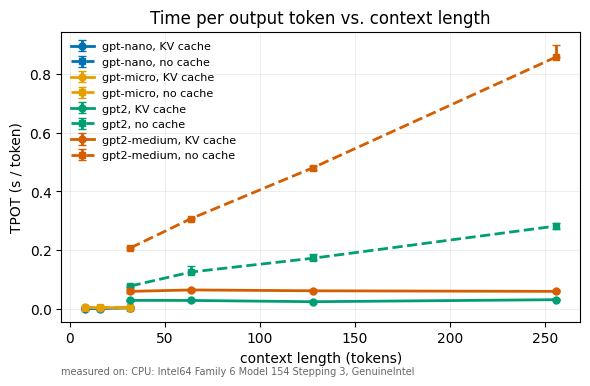

In [13]:
import matplotlib.pyplot as plt

# Okabe-Ito colorblind-safe palette, assigned in fixed order per model scale
SCALE_COLORS = {
    'gpt-nano': '#0072B2',
    'gpt-micro': '#E69F00',
    'gpt2': '#009E73',
    'gpt2-medium': '#D55E00',
}

fig, ax = plt.subplots(figsize=(6, 4))
for model_type in ALL_MODEL_TYPES:
    for cached in [True, False]:
        sub = full_sweep_df[(full_sweep_df.model_type == model_type) & (full_sweep_df.cached == cached)].sort_values('prompt_len')
        if sub.empty:
            continue
        yerr = [sub.tpot_median - sub.tpot_min, sub.tpot_max - sub.tpot_median]
        ax.errorbar(
            sub.prompt_len, sub.tpot_median, yerr=yerr,
            color=SCALE_COLORS.get(model_type, '#555555'),
            linestyle='-' if cached else '--',
            marker='o' if cached else 's',
            markersize=5, linewidth=2, capsize=3,
            label=f"{model_type}, {'KV cache' if cached else 'no cache'}",
        )

ax.set_xlabel('context length (tokens)')
ax.set_ylabel('TPOT (s / token)')
ax.set_title('Time per output token vs. context length')
ax.text(0.0, -0.18, f'measured on: {device_name()}', transform=ax.transAxes,
        fontsize=7, color='#666666', ha='left')
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'fig1_tpot_vs_context.png', dpi=150)
plt.show()


## Figure 2: Peak VRAM vs. context length, measured vs. analytical

**Only meaningful on CUDA** — `peak_memory_bytes` is `None` on CPU (see the
device note at the top), so this cell will report the analytical curve only
when run locally and skip the measured series. Re-run on Colab for the real
comparison.


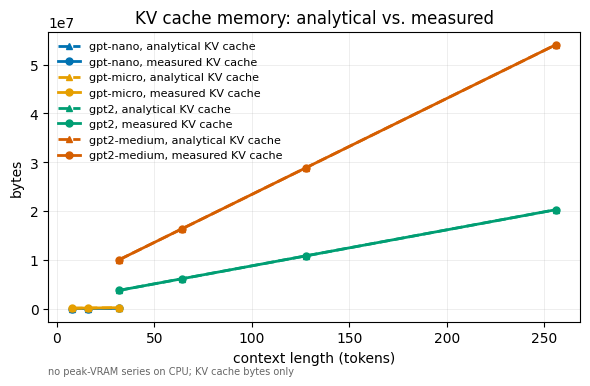

In [14]:
cache_rows = full_sweep_df[full_sweep_df.cached].sort_values('prompt_len')

fig, ax = plt.subplots(figsize=(6, 4))
for model_type in ALL_MODEL_TYPES:
    sub = cache_rows[cache_rows.model_type == model_type]
    if sub.empty:
        continue
    color = SCALE_COLORS.get(model_type, '#555555')
    ax.plot(sub.prompt_len, sub.kv_analytical_median, color=color, linestyle='--',
            marker='^', markersize=5, linewidth=2, label=f'{model_type}, analytical KV cache')
    ax.plot(sub.prompt_len, sub.kv_measured_median, color=color, linestyle='-',
            marker='o', markersize=5, linewidth=2, label=f'{model_type}, measured KV cache')
    if DEVICE == 'cuda' and sub.peak_mem_median.notna().any():
        ax.plot(sub.prompt_len, sub.peak_mem_median, color=color, linestyle=':',
                marker='s', markersize=5, linewidth=2, label=f'{model_type}, peak VRAM (measured)')

ax.set_xlabel('context length (tokens)')
ax.set_ylabel('bytes')
ax.set_title('KV cache memory: analytical vs. measured')
if DEVICE != 'cuda':
    ax.text(0.0, -0.18, 'no peak-VRAM series on CPU; KV cache bytes only', transform=ax.transAxes,
            fontsize=7, color='#666666', ha='left')
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'fig2_vram_vs_context.png', dpi=150)
plt.show()


## Pre-speculative-decoding diagnostics (local validation only)

Per `CLAUDE.md`, before writing `generate_speculative` we need two numbers:
(1) how forward-pass time scales with `T_q` (does verifying gamma+1 draft
tokens in one target pass actually stay cheap?), and (2) the cost ratio
`c = cost(draft) / cost(target)` for candidate model pairs.

**This run is local, on CPU, with `gpt-nano`/`gpt-micro` — it exists only to
de-risk the measurement code before spending Colab GPU time on it.** CPU and
GPU scale very differently with `T_q` (a GPU keeps more of that dimension
parallel), so these numbers are not the diagnostic result that goes in the
thesis — re-run the same cells on Colab with the real pairs
(`gpt-nano`/`gpt-mini`, `gpt2`/`gpt2-medium`) for that.


### Shared setup + T_q scan: does a longer verification pass stay cheap?

This cell now also defines the constants and loads the models the rest of
the speculative-decoding section depends on (`PROMPT_CATEGORIES`,
`SPEC_PROMPT_LEN`, `SPEC_MAX_NEW_TOKENS`, `SPEC_GAMMAS`, `SPEC_N_REPS`,
`target_cached`, `draft_cached`) -- moved here from the real-sweep cell below
because `v_gamma` must be measured on the model that actually performs
verification (`gpt2-medium`, the target), under conditions matched to the
real sweep, per `prompt_fig3_methodology.md`. Reusing `target_cached` here
(rather than loading a separate throwaway model) also avoids extra GPU
memory pressure.

Prefills to `representative_past_len` -- the cache length roughly halfway
through a real run (`SPEC_PROMPT_LEN + SPEC_MAX_NEW_TOKENS // 2`), not an
arbitrary `prompt_len=64` -- then, on CUDA, runs a burn-in phase (~1.5s of
throwaway forward passes) before timing anything: a freshly-loaded model's
first calls on a T4-class GPU can land while the GPU is still ramping from
idle to boost clock, which shows up as large, spurious variance at the
*first* T_q values tried, not as a real property of T_q. Left uncorrected
this doesn't just fail a sanity check -- it would bias `v_gamma` itself
(t(T_q=1) measured artificially high inflates every ratio's denominator,
making `v_gamma` artificially low and the "corrected" curve in Figure 3
artificially optimistic). Then times a single cached forward pass of `T_q`
new tokens for `T_q` in `{1..9}`. `rollback_kv_cache` resets the cache back
to the same prefill length before *each* timed variant, so all measurements
start from identical cache state -- without this, larger T_q would be timed
against a cache already grown by smaller-T_q runs, confounding the
comparison.

`tq_scans` is a dict keyed by target model name (`'gpt2-medium'` here; the
`gpt2-large` bonus cell adds its own entry later), since v_gamma depends on
where a model sits relative to the hardware's ridge point -- not the same
for two different-sized models, and not assumable without measuring.

On CPU this cell is still just a pipeline check; the numbers that matter are
what it prints when `DEVICE == 'cuda'`.


In [15]:
from mingpt.bpe import BPETokenizer

# --- shared constants and models for the whole speculative-decoding section ---
# moved here (from the real-sweep cell) so the T_q scan and cost-ratio diagnostics
# below can use the SAME target/draft models and SAME context lengths as the real
# sweep -- previously the T_q scan measured a throwaway 'gpt2' model (the DRAFT's
# architecture, not the target that actually performs verification) at an unrelated
# prompt_len=64. See prompt_fig3_methodology.md, items 1-3.
PROMPT_CATEGORIES = {
    'code': [
        "def fibonacci(n):\n    if n <= 1:\n        return n\n    return",
        "class BinaryTree:\n    def __init__(self, value):\n        self.value",
        "for i in range(len(arr) - 1):\n    if arr[i] > arr[i + 1]:",
        "import numpy as np\n\ndef normalize(x):\n    return (x - np.mean(x))",
    ],
    'factual': [
        "The capital of France is Paris, a city known for its",
        "Water boils at 100 degrees Celsius at sea level because",
        "The Great Wall of China was built over several centuries to",
        "Photosynthesis is the process by which plants convert sunlight into",
    ],
    'narrative': [
        "Once upon a time, in a small village near the mountains, there lived",
        "The old sailor stared out at the horizon, remembering the storm that",
        "She opened the door slowly, unsure of what she would find inside",
        "The forest grew darker as the sun dipped below the hills, and",
    ],
    'dialogue': [
        '"I can\'t believe you did that," she said, looking at him with',
        '"Where were you last night?" he asked, his voice trembling with',
        '"We need to talk about what happened," Sarah said quietly,',
        '"I don\'t think that\'s a good idea," Tom replied, shaking his head',
    ],
}

spec_tokenizer = BPETokenizer()

# SPEC_PROMPT_LEN sized by eyeballing word count, not the real BPE tokenizer -- several
# prompts tokenize shorter than 16, so truncating to a fixed 16 is impossible for them
# (truncation can only shorten, never pad). Use the true minimum across all 16 prompts
# instead: every prompt can still be truncated to it, and "same length for every
# prompt" -- the actual point of fixing a length -- still holds.
all_prompt_texts = [t for prompts in PROMPT_CATEGORIES.values() for t in prompts]
token_counts = {t: spec_tokenizer(t).size(1) for t in all_prompt_texts}
SPEC_PROMPT_LEN = min(token_counts.values())
print(f"SPEC_PROMPT_LEN resolved to {SPEC_PROMPT_LEN} (min token count across all 16 prompts):")
for t, n in sorted(token_counts.items(), key=lambda kv: kv[1]):
    print(f"  {n:3d}  {t!r}")

SPEC_MAX_NEW_TOKENS = 30
SPEC_GAMMAS = [1, 2, 3, 4, 5, 6, 8]
SPEC_N_REPS = 5

# Representative past (cache) length, not T_k: during a verification pass the target
# attends over T_k = past_len + T_q. Rather than scanning the full 2-D (T_k, T_q)
# space, we measure v_gamma at a cache length roughly halfway through generation.
representative_past_len = SPEC_PROMPT_LEN + SPEC_MAX_NEW_TOKENS // 2

target_cached = GPT.from_pretrained('gpt2-medium', vanilla=False).to(DEVICE).eval()
draft_cached = GPT.from_pretrained('gpt2', vanilla=False).to(DEVICE).eval()


def measure_tq_scan(model, prompt_len, tq_values=(1, 2, 3, 4, 5, 6, 7, 8, 9), n_warmup=3, n_reps=5,
                     burn_in_seconds=1.5):
    # tq_values covers T_q=1 (the v_gamma denominator) through T_q=9, i.e. gamma+1 for every
    # gamma in {1,...,8} -- SPEC_GAMMAS never exceeds 8, so this range is sufficient to
    # compute v_gamma for the whole sweep without needing to re-run this scan.
    assert not model.vanilla, "T_q scan requires a KV-cached model"
    vocab_size = model.transformer.wte.num_embeddings

    set_seed(1234)
    prompt = torch.randint(0, vocab_size, (1, prompt_len), device=DEVICE)
    model.reset_kv_cache()
    with torch.no_grad():
        model(prompt, kv_cached=False)  # prefill
    prefill_len = model.transformer.h[0].attn.k_cache.size(2)
    assert prefill_len == prompt_len

    # GPU burn-in: a freshly-loaded model's first CUDA calls can land while a T4-class
    # GPU is still ramping from idle to boost clock (DVFS), which otherwise shows up as
    # large, spurious variance concentrated at whichever T_q values are tried first --
    # not a real property of T_q, but easy to mistake for one. Run throwaway forward
    # passes at the largest T_q shape for a fixed wall-clock duration before timing
    # anything, so every T_q value below is measured on an already-ramped GPU.
    if DEVICE == 'cuda' and burn_in_seconds > 0:
        burn_shape = max(tq_values)
        burn_start = time.perf_counter()
        while time.perf_counter() - burn_start < burn_in_seconds:
            model.rollback_kv_cache(prefill_len)
            dummy = torch.randint(0, vocab_size, (1, burn_shape), device=DEVICE)
            with torch.no_grad():
                model(dummy, kv_cached=True)
        device_sync()
        model.rollback_kv_cache(prefill_len)

    rows = []
    for tq in tq_values:
        for _ in range(n_warmup):
            model.rollback_kv_cache(prefill_len)
            new_tokens = torch.randint(0, vocab_size, (1, tq), device=DEVICE)
            device_sync()
            with torch.no_grad():
                model(new_tokens, kv_cached=True)
            device_sync()

        times = []
        for _ in range(n_reps):
            model.rollback_kv_cache(prefill_len)
            new_tokens = torch.randint(0, vocab_size, (1, tq), device=DEVICE)
            device_sync()
            t0 = time.perf_counter()
            with torch.no_grad():
                model(new_tokens, kv_cached=True)
            device_sync()
            t1 = time.perf_counter()
            times.append(t1 - t0)

        s = summarize(times)
        rows.append({'T_q': tq, 'time_median': s['median'], 'time_min': s['min'], 'time_max': s['max']})

    model.rollback_kv_cache(prefill_len)  # leave cache in a clean state
    return pd.DataFrame(rows)


# tq_scans is keyed by target model name -- v_gamma depends on where a model sits
# relative to the hardware's ridge point, which differs per model size and must be
# measured, not assumed to transfer from one target to another (e.g. the gpt2-large
# bonus cell below adds its own 'gpt2-large' entry).
tq_scans = {
    'gpt2-medium': measure_tq_scan(target_cached, prompt_len=representative_past_len),
}
print(tq_scans['gpt2-medium'])

# Sanity check on the measurement code itself, NOT a scaling claim: more verified
# tokens should never cost meaningfully *less* than fewer. This only catches a
# broken rollback/measurement (e.g. accidentally reusing a shorter cache) or a
# GPU-ramp artifact the burn-in above failed to absorb; it does NOT assert linear
# scaling -- a flat curve here is a legitimate result (GPU keeping T_q parallel
# almost for free), not a failure, per CLAUDE.md's diagnostic framing. Compares
# against the median of the three LARGEST T_q values rather than T_q=1 alone, since
# T_q=1 (tried first) is the one measurement the burn-in can't fully insulate from a
# borderline-short ramp -- a real, if imperfect, safety margin rather than a loosened
# check that would let an actually-broken rollback back through.
_tq_df = tq_scans['gpt2-medium']
t1_median = _tq_df.loc[_tq_df.T_q == 1, 'time_median'].item()
large_tq_median = _tq_df.nlargest(3, 'T_q')['time_median'].median()
assert large_tq_median > t1_median * 0.5, (
    f"the three largest T_q values (median {large_tq_median:.4f}s) were notably faster "
    f"than T_q=1 ({t1_median:.4f}s) -- rollback/measurement logic is likely broken "
    f"(verifying more tokens should never cost meaningfully less than verifying fewer); "
    f"if the GPU burn-in above still isn't enough on this hardware, raise burn_in_seconds"
)
if large_tq_median <= t1_median * 1.5:
    print(f"T_q=1 median: {t1_median:.6f}s, largest-T_q median: {large_tq_median:.6f}s -- roughly flat: verification looks ~free w.r.t. T_q here")
else:
    print(f"T_q=1 median: {t1_median:.6f}s, largest-T_q median: {large_tq_median:.6f}s -- verification cost grows with T_q here")


SPEC_PROMPT_LEN resolved to 10 (min token count across all 16 prompts):
   10  'Water boils at 100 degrees Celsius at sea level because'
   11  'The Great Wall of China was built over several centuries to'
   11  'Photosynthesis is the process by which plants convert sunlight into'
   12  'The capital of France is Paris, a city known for its'
   13  'The old sailor stared out at the horizon, remembering the storm that'
   13  'She opened the door slowly, unsure of what she would find inside'
   13  'The forest grew darker as the sun dipped below the hills, and'
   13  '"We need to talk about what happened," Sarah said quietly,'
   14  '"Where were you last night?" he asked, his voice trembling with'
   15  'Once upon a time, in a small village near the mountains, there lived'
   16  '"I can\'t believe you did that," she said, looking at him with'
   17  '"I don\'t think that\'s a good idea," Tom replied, shaking his head'
   27  'import numpy as np\n\ndef normalize(x):\n    return (x -

number of parameters: 354.82M


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 292/292 [00:00<00:00, 9125.93it/s]

MinGPT model has: 317 parameters
HuggingFace checkpoint has: 293 parameters
Keys to copy: 293


number of parameters: 124.44M


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6356.96it/s]

MinGPT model has: 161 parameters
HuggingFace checkpoint has: 149 parameters
Keys to copy: 149


   T_q  time_median  time_min  time_max
0    1     0.055948  0.054959  0.058557
1    2     0.077521  0.074151  0.079184
2    3     0.074844  0.073169  0.083447
3    4     0.075706  0.074436  0.076610
4    5     0.085185  0.081981  0.099587
5    6     0.077865  0.076569  0.080061
6    7     0.079407  0.078016  0.080205
7    8     0.085453  0.084822  0.086560
8    9     0.096505  0.092846  0.097019
T_q=1 median: 0.055948s, largest-T_q median: 0.085453s -- verification cost grows with T_q here


### Cost ratio c = cost(draft) / cost(target)

Reuses `benchmark_config` unchanged, and now reuses `target_cached`/
`draft_cached` from the cell above (rather than loading separate copies) at
`SPEC_PROMPT_LEN`/`SPEC_MAX_NEW_TOKENS` -- matching conditions with the real
sweep and with the T_q scan, since `c`, `v_gamma`, and measured speedup all
feed the same Figure 3 comparison and should not be measured under three
different setups. See `prompt_fig3_methodology.md`, item 3.


In [16]:
def measure_cost_ratio(draft_model, target_model, prompt_len, max_new_tokens, n_reps=5):
    vocab_size = min(draft_model.transformer.wte.num_embeddings, target_model.transformer.wte.num_embeddings)
    set_seed(1234)
    prompt = torch.randint(0, vocab_size, (1, prompt_len), device=DEVICE)
    draft_result = benchmark_config(draft_model, prompt, max_new_tokens=max_new_tokens, n_reps=n_reps)
    target_result = benchmark_config(target_model, prompt, max_new_tokens=max_new_tokens, n_reps=n_reps)
    c = draft_result['summary']['tpot']['median'] / target_result['summary']['tpot']['median']
    return c, draft_result, target_result


# reuses target_cached/draft_cached loaded in the T_q scan cell above -- both are
# needed again for the real sweep below, so they are not deleted here
c_ratio, draft_result, target_result = measure_cost_ratio(
    draft_cached, target_cached, prompt_len=SPEC_PROMPT_LEN, max_new_tokens=SPEC_MAX_NEW_TOKENS,
)
print(f"draft (gpt2) TPOT median:        {draft_result['summary']['tpot']['median']:.6f}s")
print(f"target (gpt2-medium) TPOT median: {target_result['summary']['tpot']['median']:.6f}s")
print(f"c = cost(draft)/cost(target) = {c_ratio:.3f}")

assert c_ratio < 1.0, "expected the smaller gpt2 draft to be cheaper per token than the gpt2-medium target"
print("measurement code looks sane: draft is cheaper than target, as expected")


draft (gpt2) TPOT median:        0.022564s
target (gpt2-medium) TPOT median: 0.057168s
c = cost(draft)/cost(target) = 0.395
measurement code looks sane: draft is cheaper than target, as expected


## Figures 3-5 and summary table: speculative decoding

`generate_speculative` (Phase A, greedy) is implemented in `mingpt/model.py` and
passes its identity test in `tests/test_speculative.py` (all vanilla/cached
combinations, the overshoot guard, the draft-size guard, and real
`gpt2`/`gpt2-medium` weights) -- this section wall-clock benchmarks it the same
way the cells above benchmark `generate`, and builds the three remaining
figures from `CLAUDE.md`.

Same rule as before: an empty cell/row is honest, a fabricated one is worse
than no data. The toy-model pipeline check below exists only to prove the
benchmarking code itself runs without crashing -- its alpha numbers are
meaningless (untrained, random-token models agreeing on argmax is a coin
flip) and must never appear in Figures 3-4. Only the `gpt2`/`gpt2-medium`
(and optional `gpt2-large`) cells, hard-gated behind `DEVICE == 'cuda'` and
run on a Colab GPU, produce numbers that belong in the thesis.

### `run_once_speculative` / `benchmark_config_speculative`

Parallel to `run_once` / `benchmark_config` above, with three differences:

- TTFT is still measured as a dedicated target-only prefill pass -- this is
  the same first step `generate_speculative` itself performs before any draft
  proposal happens, so reusing the idea (not the code) is legitimate.
- `alpha` comes from `return_stats=True` on the *same timed call*, not a
  separate untimed run -- an untimed measurement could in principle drift
  from what was actually timed.
- The overshoot guard already has a unit test
  (`TestSpeculativeOvershootGuard`), but a benchmark run that silently
  produced the wrong number of tokens would corrupt every downstream
  throughput/TPOT number without necessarily crashing -- so it is re-asserted
  here as a benchmark-time invariant, not just a correctness-time one.
- `benchmark_config_speculative` additionally asserts alpha is identical
  across all `n_reps` repeats: Phase A is fully greedy and deterministic, so
  any variation is a state-leak bug (e.g. a cache not actually reset between
  repeats), not measurement noise.

In [17]:
def _cache_len_and_dtype(model, out):
    # See prompt_prefinal_fixes.md, P0-2: cached generate()/generate_speculative()
    # maintain T_cache = T_output - 1 (the most recently committed token hasn't been
    # fed through a forward pass yet), so using out.size(1) directly overstates the
    # analytical KV size by exactly one token's worth of bytes. Read the real cache
    # length and dtype instead of assuming either.
    if not model.vanilla:
        return model.transformer.h[0].attn.k_cache.size(2), model.transformer.h[0].attn.k_cache.dtype
    return out.size(1), torch.float32


@torch.no_grad()
def run_once_speculative(target, draft, idx, max_new_tokens, gamma,
                          do_sample=False, top_k=None, temperature=1.0):
    idx_cond = idx if idx.size(1) <= target.block_size else idx[:, -target.block_size:]

    # --- TTFT: dedicated prefill-only forward pass, target only (mirrors the
    # first step generate_speculative itself performs before any draft proposal) ---
    if not target.vanilla:
        target.reset_kv_cache()
    device_sync()
    t0 = time.perf_counter()
    target(idx_cond, kv_cached=False)
    device_sync()
    t1 = time.perf_counter()
    ttft = t1 - t0
    if not target.vanilla:
        target.reset_kv_cache()
    if not draft.vanilla:
        draft.reset_kv_cache()

    # --- full speculative generation, timed as a whole ---
    reset_peak_memory()
    device_sync()
    t2 = time.perf_counter()
    out, stats = target.generate_speculative(
        draft, idx, max_new_tokens=max_new_tokens, gamma=gamma,
        do_sample=do_sample, top_k=top_k, temperature=temperature,
        return_stats=True,
    )
    device_sync()
    t3 = time.perf_counter()
    total_time = t3 - t2

    generated_tokens = out.size(1) - idx.size(1)
    assert generated_tokens == max_new_tokens, (
        f"generate_speculative returned {generated_tokens} new tokens, expected "
        f"{max_new_tokens} -- the overshoot guard is unit-tested elsewhere, but a "
        f"wrong token count here would silently corrupt every downstream "
        f"throughput/TPOT number computed from this run"
    )

    tpot = (total_time - ttft) / (generated_tokens - 1) if generated_tokens > 1 else float('nan')
    throughput = generated_tokens / total_time

    # computed SEPARATELY for target and draft: their final cache states don't
    # necessarily carry the same lag, especially after the full-accept
    # synchronization path (see prompt_prefinal_fixes.md, P0-2)
    target_len, target_dtype = _cache_len_and_dtype(target, out)
    kv_analytical_target = analytical_kv_cache_bytes(out.size(0), target.num_layers,
                                                      target.transformer.wte.embedding_dim,
                                                      target_len, dtype=target_dtype)
    draft_len, draft_dtype = _cache_len_and_dtype(draft, out)
    kv_analytical_draft = analytical_kv_cache_bytes(out.size(0), draft.num_layers,
                                                     draft.transformer.wte.embedding_dim,
                                                     draft_len, dtype=draft_dtype)

    return {
        'ttft': ttft,
        'total_time': total_time,
        'tpot': tpot,
        'throughput': throughput,
        # target + draft combined: one CUDA device, one global peak-memory counter
        'peak_memory_bytes': peak_memory_bytes(),
        'kv_cache_measured_bytes_target': measured_kv_cache_bytes(target) if not target.vanilla else 0,
        'kv_cache_measured_bytes_draft': measured_kv_cache_bytes(draft) if not draft.vanilla else 0,
        'kv_cache_analytical_bytes_target': kv_analytical_target,
        'kv_cache_analytical_bytes_draft': kv_analytical_draft,
        'seq_len': out.size(1),
        'proposed': stats['proposed'],
        'accepted': stats['accepted'],
        'tested': stats['tested'],
        # 'alpha' is kept only for backward compatibility -- it is accepted_fraction
        # (accepted / ALL proposed, including untested positions after a rejection),
        # NOT the analytical model's per-token conditional acceptance probability.
        # Use 'alpha_conditional' for the theoretical speedup formula and Figures 3/4.
        # See prompt_alpha_and_cache_fixes.md, Problem 2.
        'alpha': stats['alpha'],
        'alpha_conditional': stats['alpha_conditional'],
        'accepted_fraction': stats['accepted_fraction'],
        'expected_accepted_per_round': stats['expected_accepted_per_round'],
        'rounds': stats['rounds'],
        # raw per-round sequences -- deterministic under greedy Phase A, used by the
        # E[A] validation cell to compare against each round's ACTUAL block length
        # rather than assuming every round ran the full gamma (see P1-5)
        'accepted_per_round': stats['accepted_per_round'],
        'g_per_round': stats['g_per_round'],
        'out': out,
    }


def benchmark_config_speculative(target, draft, idx, max_new_tokens, gamma,
                                  n_warmup=3, n_reps=5, **gen_kwargs):
    for _ in range(n_warmup):
        run_once_speculative(target, draft, idx, max_new_tokens, gamma, **gen_kwargs)

    metrics = ['ttft', 'total_time', 'tpot', 'throughput', 'peak_memory_bytes',
               'kv_cache_measured_bytes_target', 'kv_cache_measured_bytes_draft',
               'kv_cache_analytical_bytes_target', 'kv_cache_analytical_bytes_draft',
               'proposed', 'accepted', 'tested', 'alpha',
               'alpha_conditional', 'accepted_fraction', 'expected_accepted_per_round', 'rounds']
    raw = {m: [] for m in metrics}
    g_per_round_by_rep = []
    accepted_per_round_by_rep = []
    for _ in range(n_reps):
        result = run_once_speculative(target, draft, idx, max_new_tokens, gamma, **gen_kwargs)
        for m in metrics:
            raw[m].append(result[m])
        g_per_round_by_rep.append(result['g_per_round'])
        accepted_per_round_by_rep.append(result['accepted_per_round'])

    # Phase A is fully greedy and deterministic: acceptance metrics AND the raw
    # per-round sequences must be identical across every repeat. Any variation here
    # is a state-leak bug (e.g. a cache not actually reset between repeats), not
    # ordinary measurement noise -- fail loudly instead of quietly averaging it away.
    for key in ('alpha', 'alpha_conditional'):
        vals = raw[key]
        assert all(v == vals[0] for v in vals), (
            f"{key} varied across repeats under greedy (do_sample=False) decoding: {vals} "
            f"-- this indicates non-deterministic state leaking between repeats, not "
            f"measurement noise; investigate before trusting any number from this run"
        )
    assert all(g == g_per_round_by_rep[0] for g in g_per_round_by_rep), (
        "g_per_round varied across repeats under greedy decoding -- non-deterministic "
        "state leaking between repeats"
    )
    assert all(a == accepted_per_round_by_rep[0] for a in accepted_per_round_by_rep), (
        "accepted_per_round varied across repeats under greedy decoding -- non-deterministic "
        "state leaking between repeats"
    )

    return {
        'n_warmup': n_warmup,
        'n_reps': n_reps,
        'prompt_len': idx.size(1),
        'max_new_tokens': max_new_tokens,
        'gamma': gamma,
        'raw': raw,
        'summary': {m: summarize(raw[m]) for m in metrics},
        # deterministic under greedy Phase A -- same every rep, so just keep one copy
        'g_per_round': g_per_round_by_rep[0],
        'accepted_per_round': accepted_per_round_by_rep[0],
    }


def save_result_speculative(name, target_type, draft_type, cached, benchmark_result):
    payload = {
        'metadata': {
            'gpu_type': device_name(),
            'device': DEVICE,
            'torch_version': torch.__version__,
            'seed': SEED,
            'target_model_type': target_type,
            'draft_model_type': draft_type,
            'cached': cached,
            'gamma': benchmark_result['gamma'],
            'prompt_len': benchmark_result['prompt_len'],
            'max_new_tokens': benchmark_result['max_new_tokens'],
            'alpha': benchmark_result['summary']['alpha']['median'],
            'alpha_conditional': benchmark_result['summary']['alpha_conditional']['median'],
            'accepted_fraction': benchmark_result['summary']['accepted_fraction']['median'],
            'expected_accepted_per_round': benchmark_result['summary']['expected_accepted_per_round']['median'],
            'proposed': benchmark_result['summary']['proposed']['median'],
            'accepted': benchmark_result['summary']['accepted']['median'],
            'tested': benchmark_result['summary']['tested']['median'],
            'g_per_round': benchmark_result['g_per_round'],
            'accepted_per_round': benchmark_result['accepted_per_round'],
        },
        'summary': benchmark_result['summary'],
        'raw': benchmark_result['raw'],
    }
    path = RESULTS_DIR / f"{name}.json"
    with open(path, 'w') as f:
        json.dump(payload, f, indent=2)
    return path


### Pipeline check (CPU, toy models) -- proves the harness works, nothing else

Same role as the smoke test earlier in this notebook: random untrained
`gpt-nano`/`gpt-micro` models, so `alpha` here is pure noise by construction
(two random models agreeing on argmax is a coin flip, not a measurement).
This only exists to catch a broken `run_once_speculative` /
`benchmark_config_speculative` before spending Colab GPU time on the real
sweep below. Never cite these numbers.

In [18]:
set_seed(1234)
toy_spec_target = GPT(make_toy_config(model_type='gpt-micro'), vanilla=False).to(DEVICE).eval()
set_seed(1234)
toy_spec_draft = GPT(make_toy_config(model_type='gpt-nano'), vanilla=False).to(DEVICE).eval()

toy_spec_prompt = torch.randint(0, 100, (1, 8), device=DEVICE)

pipeline_check = benchmark_config_speculative(toy_spec_target, toy_spec_draft, toy_spec_prompt,
                                               max_new_tokens=10, gamma=3, n_warmup=1, n_reps=2)

assert pipeline_check['summary']['tpot']['median'] is not None
assert pipeline_check['summary']['alpha']['median'] is not None
assert pipeline_check['summary']['alpha_conditional']['median'] is not None
print('pipeline check alpha / alpha_conditional (MEANINGLESS -- random untrained models):',
      pipeline_check['summary']['alpha']['median'], '/', pipeline_check['summary']['alpha_conditional']['median'])
print('pipeline check passed: run_once_speculative / benchmark_config_speculative run end-to-end')

del toy_spec_target, toy_spec_draft


number of parameters: 0.81M
number of parameters: 0.09M


pipeline check alpha / alpha_conditional (MEANINGLESS -- random untrained models): 0.0 / 0.0
pipeline check passed: run_once_speculative / benchmark_config_speculative run end-to-end


### Real gamma sweep: `gpt2` (draft) / `gpt2-medium` (target) -- requires Colab GPU

`PROMPT_CATEGORIES`, `SPEC_PROMPT_LEN`, `SPEC_MAX_NEW_TOKENS`, `SPEC_GAMMAS`,
`SPEC_N_REPS`, `target_cached`, and `draft_cached` are already defined in the
T_q scan cell above (moved there so the T_q scan and cost-ratio diagnostics
use the exact same models and context lengths as this sweep). This cell adds
the two vanilla (uncached) models needed for the baseline and
isolated-contribution rows, then runs the sweep.

Unlike the smaller diagnostic cells above (T_q scan, cost ratio), which are
cheap enough to double as CPU pipeline checks, this is a full category x
prompt x gamma matrix on gpt2-medium -- too slow to be a meaningful CPU
pipeline check too, so it is hard-gated behind `DEVICE == 'cuda'`. The
toy-model cell above is what stands in for the CPU pipeline check here.
Expect this cell to take a few minutes on a T4.


In [19]:
if DEVICE == 'cuda':
    target_vanilla = GPT.from_pretrained('gpt2-medium', vanilla=True).to(DEVICE).eval()
    draft_vanilla = GPT.from_pretrained('gpt2', vanilla=True).to(DEVICE).eval()

    def tokenize_fixed_len(text, length=SPEC_PROMPT_LEN):
        ids = spec_tokenizer(text).to(DEVICE)
        assert ids.size(1) >= length, (
            f"prompt {text!r} tokenizes to only {ids.size(1)} tokens, need at least {length}"
        )
        return ids[:, :length]

    # --- main sweep: cached target / cached draft, every category x prompt x gamma ---
    spec_rows = []
    for category, prompts in PROMPT_CATEGORIES.items():
        for prompt_idx, prompt_text in enumerate(prompts):
            prompt = tokenize_fixed_len(prompt_text)
            for gamma in SPEC_GAMMAS:
                result = benchmark_config_speculative(
                    target_cached, draft_cached, prompt,
                    max_new_tokens=SPEC_MAX_NEW_TOKENS, gamma=gamma, n_reps=SPEC_N_REPS,
                )
                save_result_speculative(
                    f"spec_cached_{category}_{prompt_idx}_gamma{gamma}",
                    'gpt2-medium', 'gpt2', True, result,
                )
                spec_rows.append({
                    'category': category,
                    'prompt_idx': prompt_idx,
                    'gamma': gamma,
                    'throughput_median': result['summary']['throughput']['median'],
                    'tpot_median': result['summary']['tpot']['median'],
                    'peak_mem_median': result['summary']['peak_memory_bytes']['median'],
                    'alpha': result['summary']['alpha']['median'],
                    'alpha_conditional': result['summary']['alpha_conditional']['median'],
                    'accepted_fraction': result['summary']['accepted_fraction']['median'],
                    'expected_accepted_per_round': result['summary']['expected_accepted_per_round']['median'],
                    'proposed': result['summary']['proposed']['median'],
                    'accepted': result['summary']['accepted']['median'],
                    'tested': result['summary']['tested']['median'],
                    # raw per-round sequences (deterministic under greedy), used by the
                    # E[A] validation cell against each round's ACTUAL block length
                    'g_per_round': result['g_per_round'],
                    'accepted_per_round': result['accepted_per_round'],
                })
    spec_df = pd.DataFrame(spec_rows)

    # --- reference prompt for the bounded vanilla/vanilla row and the baseline/cache-only rows ---
    ref_prompt_text = PROMPT_CATEGORIES['factual'][0]
    ref_prompt = tokenize_fixed_len(ref_prompt_text)

    baseline_result = benchmark_config(target_vanilla, ref_prompt,
                                        max_new_tokens=SPEC_MAX_NEW_TOKENS, n_reps=SPEC_N_REPS)
    cache_only_result = benchmark_config(target_cached, ref_prompt,
                                          max_new_tokens=SPEC_MAX_NEW_TOKENS, n_reps=SPEC_N_REPS)
    save_result('spec_ref_baseline_gpt2medium', 'gpt2-medium', False, baseline_result)
    save_result('spec_ref_cacheonly_gpt2medium', 'gpt2-medium', True, cache_only_result)

    # --- isolated-contribution row: speculative decoding with NO cache on either side ---
    vanilla_spec_rows = []
    for gamma in SPEC_GAMMAS:
        result = benchmark_config_speculative(
            target_vanilla, draft_vanilla, ref_prompt,
            max_new_tokens=SPEC_MAX_NEW_TOKENS, gamma=gamma, n_reps=SPEC_N_REPS,
        )
        save_result_speculative(f"spec_vanilla_gamma{gamma}", 'gpt2-medium', 'gpt2', False, result)
        vanilla_spec_rows.append({
            'gamma': gamma,
            'throughput_median': result['summary']['throughput']['median'],
            'tpot_median': result['summary']['tpot']['median'],
            'peak_mem_median': result['summary']['peak_memory_bytes']['median'],
            'alpha': result['summary']['alpha']['median'],
            'alpha_conditional': result['summary']['alpha_conditional']['median'],
            'accepted_fraction': result['summary']['accepted_fraction']['median'],
            'expected_accepted_per_round': result['summary']['expected_accepted_per_round']['median'],
        })
    vanilla_spec_df = pd.DataFrame(vanilla_spec_rows)

    print(f"cached/cached sweep: {len(spec_df)} rows across {len(PROMPT_CATEGORIES)} categories")
    print("alpha (old, biased-low metric) by gamma:")
    print(spec_df.groupby('gamma')['alpha'].mean())
    print("alpha_conditional (corrected per-token estimate) by gamma:")
    print(spec_df.groupby('gamma')['alpha_conditional'].mean())
else:
    print("DEVICE != 'cuda': skipping the real gpt2/gpt2-medium sweep. "
          "Re-run this cell on a Colab GPU runtime to produce real Figure 3-5 data. "
          "The toy-model pipeline check above already validated the benchmarking code.")


DEVICE != 'cuda': skipping the real gpt2/gpt2-medium sweep. Re-run this cell on a Colab GPU runtime to produce real Figure 3-5 data. The toy-model pipeline check above already validated the benchmarking code.


## Figure 3: speedup vs. gamma, measured vs. two analytical predictions

Two curves, not one, per `prompt_prefinal_fixes.md` (P0-4):

- **idealized prediction** (`v_gamma = 1`): the original formula, which assumes
  verifying gamma+1 tokens with the target costs the same as one ordinary
  target step. This assumption is exactly what the T_q scan above tests, and
  it is not guaranteed to hold.
- **v_gamma-corrected prediction**: replaces that assumption with
  `v_gamma = t_target(T_q=gamma+1) / t_target(T_q=1)`, measured directly from
  `tq_scans['gpt2-medium']` above. If the GPU keeps T_q parallel almost for
  free, v_gamma is close to 1 and the two curves nearly coincide -- itself a
  reportable result.

Both predictions are averaged **per prompt, then across prompts**
(`mean(S(alpha_i))`), not computed once from the mean alpha
(`S(mean(alpha_i))`) -- `S` is convex in alpha (a positive-weighted sum of
`alpha^k` terms, each convex on `[0,1]`), so by Jensen's inequality
`S(mean(alpha))` systematically *understates* the correct average
prediction. See `prompt_fig3_methodology.md`, item 4. The spread across
prompts (min/max) is plotted alongside the mean, the same way other metrics
in this notebook report median and range rather than a single number.

Neither curve is a "bound": exceeding one by more than plausible noise is
worth checking (were baseline and speculative measured under comparable
conditions?), not proof of an error -- see the NOTE this cell prints if that
happens.


In [20]:
if DEVICE == 'cuda':
    tq_scan_medium = tq_scans['gpt2-medium']
    t1_median = tq_scan_medium.loc[tq_scan_medium.T_q == 1, 'time_median'].item()

    def get_v_gamma(tq_scan, gamma):
        # v_gamma = t_target(T_q=gamma+1) / t_target(T_q=1), from the given T_q scan.
        # Must be measured on the model that actually performs verification (the
        # target), not an unrelated model -- see prompt_fig3_methodology.md, item 1.
        row = tq_scan.loc[tq_scan.T_q == gamma + 1, 'time_median']
        assert not row.empty, (
            f"T_q scan doesn't cover T_q={gamma + 1} (needed for gamma={gamma}); "
            f"extend tq_values in the T_q scan cell above"
        )
        t1 = tq_scan.loc[tq_scan.T_q == 1, 'time_median'].item()
        return row.item() / t1

    def predicted_speedup(gamma, alpha, denom_v):
        # See prompt_prefinal_fixes.md, P0-3: the alpha->1 limit of the FULL expression
        # is (gamma+1)/(gamma*c+denom_v), not just the numerator's limit (gamma+1) --
        # the old code dropped the denominator's non-alpha factor entirely in this branch.
        if abs(1 - alpha) < 1e-9:
            return (gamma + 1) / (gamma * c_ratio + denom_v)
        return (1 - alpha ** (gamma + 1)) / ((1 - alpha) * (gamma * c_ratio + denom_v))

    speedup_rows = []
    baseline_cache_throughput = cache_only_result['summary']['throughput']['median']
    for gamma in SPEC_GAMMAS:
        sub = spec_df[spec_df.gamma == gamma]
        mean_throughput = sub['throughput_median'].mean()
        measured_speedup = mean_throughput / baseline_cache_throughput

        v_gamma = get_v_gamma(tq_scan_medium, gamma)

        # S(alpha) is convex in alpha (a positive-weighted sum of alpha^k terms, each
        # convex on [0,1]), so by Jensen's inequality S(mean(alpha)) systematically
        # UNDERSTATES mean(S(alpha)) -- average the prediction per prompt, not the
        # alpha. See prompt_fig3_methodology.md, item 4.
        idealized_per_prompt = [predicted_speedup(gamma, a, denom_v=1.0) for a in sub['alpha_conditional']]
        corrected_per_prompt = [predicted_speedup(gamma, a, denom_v=v_gamma) for a in sub['alpha_conditional']]
        idealized_speedup = sum(idealized_per_prompt) / len(idealized_per_prompt)
        corrected_speedup = sum(corrected_per_prompt) / len(corrected_per_prompt)

        if measured_speedup > idealized_speedup * 1.15:
            print(f"NOTE: gamma={gamma} measured speedup ({measured_speedup:.2f}) exceeds "
                  f"the idealized prediction ({idealized_speedup:.2f}) by more than plausible "
                  f"noise -- worth checking whether baseline and speculative runs were measured "
                  f"under comparable conditions. Exceeding an idealized (not guaranteed) "
                  f"prediction is informative, not necessarily an error.")

        speedup_rows.append({
            'gamma': gamma, 'alpha_conditional_mean': sub['alpha_conditional'].mean(), 'v_gamma': v_gamma,
            'measured_speedup': measured_speedup,
            'idealized_speedup': idealized_speedup,
            'idealized_speedup_min': min(idealized_per_prompt),
            'idealized_speedup_max': max(idealized_per_prompt),
            'corrected_speedup': corrected_speedup,
            'corrected_speedup_min': min(corrected_per_prompt),
            'corrected_speedup_max': max(corrected_per_prompt),
        })
    speedup_df = pd.DataFrame(speedup_rows)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(speedup_df.gamma, speedup_df.measured_speedup, color='#0072B2', linestyle='-',
            marker='o', markersize=5, linewidth=2, label='measured (gpt2-medium / gpt2)')

    idealized_yerr = [speedup_df.idealized_speedup - speedup_df.idealized_speedup_min,
                       speedup_df.idealized_speedup_max - speedup_df.idealized_speedup]
    ax.errorbar(speedup_df.gamma, speedup_df.idealized_speedup, yerr=idealized_yerr,
                color='#0072B2', linestyle='--', marker='^', markersize=5, linewidth=2, capsize=3,
                label=f'idealized prediction, c={c_ratio:.2f}, v_gamma=1 (mean(S(alpha_i)) +/- range)')

    corrected_yerr = [speedup_df.corrected_speedup - speedup_df.corrected_speedup_min,
                       speedup_df.corrected_speedup_max - speedup_df.corrected_speedup]
    ax.errorbar(speedup_df.gamma, speedup_df.corrected_speedup, yerr=corrected_yerr,
                color='#009E73', linestyle=':', marker='s', markersize=5, linewidth=2, capsize=3,
                label=f'v_gamma-corrected prediction, c={c_ratio:.2f} (mean(S(alpha_i)) +/- range)')

    ax.axhline(1.0, color='#666666', linestyle=':', linewidth=1)
    ax.set_xlabel('gamma')
    ax.set_ylabel('speedup vs. cache-only baseline')
    ax.set_title('Speculative decoding speedup vs. gamma (gpt2-medium target / gpt2 draft)')
    ax.text(0.0, -0.18, f'measured on: {device_name()}', transform=ax.transAxes,
            fontsize=7, color='#666666', ha='left')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.legend(frameon=False, fontsize=7)
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / 'fig3_speedup_vs_gamma.png', dpi=150)
    plt.show()
    speedup_df
else:
    print("DEVICE != 'cuda': Figure 3 needs the real sweep above; nothing to plot on CPU.")


DEVICE != 'cuda': Figure 3 needs the real sweep above; nothing to plot on CPU.


## Figure 4: acceptance rate (alpha) vs. gamma, by prompt category

Uses 4 prompts per category from the sweep above (not the earlier
single-prompt-per-category pilot measurement, which is discarded -- kept
only in this notebook's/chat's history as a sanity check that the mechanism
worked, never as final data). Mean and range (min/max) across the 4 prompts
in each category, same convention as TPOT's median/range elsewhere in this
notebook.

In [21]:
if DEVICE == 'cuda':
    CATEGORY_COLORS = {
        'code': '#0072B2',
        'factual': '#E69F00',
        'narrative': '#009E73',
        'dialogue': '#D55E00',
    }
    fig, ax = plt.subplots(figsize=(6, 4))
    for category in PROMPT_CATEGORIES:
        cat_df = spec_df[spec_df.category == category]

        sub_cond = cat_df.groupby('gamma')['alpha_conditional'].agg(['mean', 'min', 'max']).reset_index()
        yerr_cond = [sub_cond['mean'] - sub_cond['min'], sub_cond['max'] - sub_cond['mean']]
        ax.errorbar(sub_cond.gamma, sub_cond['mean'], yerr=yerr_cond, color=CATEGORY_COLORS[category],
                    linestyle='-', marker='o', markersize=5, linewidth=2, capsize=3,
                    label=f'{category} (alpha_conditional)')

        # accepted_fraction shown as a second, visually distinct series (dashed, no
        # error bars) -- makes concrete that it is a different, smaller quantity that
        # declines with gamma even when alpha_conditional does not, per Problem 2
        sub_frac = cat_df.groupby('gamma')['accepted_fraction'].mean().reset_index()
        ax.plot(sub_frac.gamma, sub_frac['accepted_fraction'], color=CATEGORY_COLORS[category],
                linestyle=':', marker=None, linewidth=1, alpha=0.6)

    ax.set_xlabel('gamma')
    ax.set_ylabel('acceptance rate')
    ax.set_title('Acceptance rate vs. gamma, by category: alpha_conditional (solid) vs.\naccepted_fraction (dotted) -- gpt2-medium / gpt2')
    ax.set_ylim(0, 1)
    n_prompts = len(next(iter(PROMPT_CATEGORIES.values())))
    ax.text(0.0, -0.22, f'measured on: {device_name()}, {SPEC_N_REPS} reps/prompt, {n_prompts} prompts/category',
            transform=ax.transAxes, fontsize=7, color='#666666', ha='left')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.legend(frameon=False, fontsize=7, title='prompt category', ncol=2)
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / 'fig4_alpha_vs_gamma_by_category.png', dpi=150)
    plt.show()
else:
    print("DEVICE != 'cuda': Figure 4 needs the real sweep above; nothing to plot on CPU.")


DEVICE != 'cuda': Figure 4 needs the real sweep above; nothing to plot on CPU.


## E[A] validation: does the independence assumption hold?

Compares, **per row** (one row = one category/prompt/gamma combination), the
**measured** `expected_accepted_per_round` against the **analytical**
expectation computed from that row's own `alpha_conditional` *and* its own
actual `g_per_round` sequence -- not a blanket `alpha + alpha^2 + ... +
alpha^gamma` that assumes every round ran the full gamma. With
`SPEC_MAX_NEW_TOKENS=30` and gamma up to 8, the last round in a sweep is
frequently shorter than gamma, so that assumption would be wrong often enough
to matter (see `prompt_prefinal_fixes.md`, P1-5).

If measured and analytical agree, acceptance is effectively independent
across positions within a block. If measured E[A] systematically deviates,
that is direct evidence of correlation between acceptances -- a limitation
the thesis already states qualitatively, but this turns it into a measured
finding. Either outcome is legitimate to report; nothing here is tuned to
force agreement.


In [22]:
if DEVICE == 'cuda':
    ea_rows = []
    for gamma in SPEC_GAMMAS:
        sub = spec_df[spec_df.gamma == gamma]
        row_measured = []
        row_analytical = []
        for _, row in sub.iterrows():
            alpha_row = row['alpha_conditional']
            # analytical E[A] for THIS row's actual sequence of round lengths, not a
            # blanket range(1, gamma+1) -- the final round is frequently shorter
            g_lengths = row['g_per_round']
            analytical_ea_row = sum(
                sum(alpha_row ** k for k in range(1, g + 1)) for g in g_lengths
            ) / len(g_lengths)
            row_analytical.append(analytical_ea_row)
            row_measured.append(row['expected_accepted_per_round'])

        ea_rows.append({
            'gamma': gamma,
            'alpha_conditional_mean': sub['alpha_conditional'].mean(),
            'measured_E[A]_mean': sum(row_measured) / len(row_measured),
            'analytical_E[A]_mean': sum(row_analytical) / len(row_analytical),
            'diff_mean': (sum(row_measured) - sum(row_analytical)) / len(row_measured),
        })
    ea_df = pd.DataFrame(ea_rows)
    print("E[A] validation -- per-row analytical expectation uses each row's own actual")
    print("per-round block lengths (g_per_round), not a blanket range(1, gamma+1), since the")
    print("final round in a sweep is frequently shorter than gamma. Does the independence")
    print("assumption behind the geometric-series speedup formula hold empirically? A large")
    print("systematic diff is evidence acceptances are correlated across positions, not a bug.")
    ea_df
else:
    print("DEVICE != 'cuda': E[A] validation needs the real sweep above; nothing to compute on CPU.")


DEVICE != 'cuda': E[A] validation needs the real sweep above; nothing to compute on CPU.


## Figure 5: summary table (baseline / cache / cache+speculative / vanilla+speculative)

One row per (model pair, configuration). Toy-scale rows are pulled from the
JSON files already saved by the Figure 1 sweep (`bench_results/*_ctx16.json`)
rather than re-measured -- their alpha is left as `None`, since no
speculative decoding is meaningful on untrained models. Real gpt2-family rows
use a single representative gamma (`SUMMARY_GAMMA`) for this one-row-per-config
view; the full gamma dependence is Figure 3, not this table.

In [23]:
if DEVICE == 'cuda':
    SUMMARY_GAMMA = 4  # representative gamma for this table; Figure 3 has the full sweep
    assert SUMMARY_GAMMA in SPEC_GAMMAS, (
        f"SUMMARY_GAMMA={SUMMARY_GAMMA} was not part of SPEC_GAMMAS={SPEC_GAMMAS}; "
        f"pick a SUMMARY_GAMMA that was actually swept above, or this table can't be built"
    )
    TOY_REF_LEN = 16   # matches one of Figure 1's CONTEXT_LENGTHS

    def load_saved(name):
        with open(RESULTS_DIR / f"{name}.json") as f:
            return json.load(f)

    summary_rows = []

    # --- toy-scale rows, reused from Figure 1's already-saved JSON, not re-measured ---
    for model_type in MODEL_TYPES:
        baseline_saved = load_saved(f"{model_type}_baseline_ctx{TOY_REF_LEN}")
        baseline_tp = baseline_saved['summary']['throughput']['median']
        for cached in [True, False]:
            saved = load_saved(f"{model_type}_{'cache' if cached else 'baseline'}_ctx{TOY_REF_LEN}")
            tp = saved['summary']['throughput']['median']
            summary_rows.append({
                'model_pair': model_type, 'config': 'cache' if cached else 'baseline', 'gamma': None,
                'throughput': tp, 'tpot': saved['summary']['tpot']['median'],
                'peak_mem_bytes': saved['summary']['peak_memory_bytes']['median'], 'alpha_conditional': None,
                'speedup_vs_vanilla': tp / baseline_tp,
            })

    # --- real gpt2-medium / gpt2 rows ---
    real_baseline_tp = baseline_result['summary']['throughput']['median']
    cache_spec_at_gamma = spec_df[spec_df.gamma == SUMMARY_GAMMA]
    vanilla_spec_at_gamma = vanilla_spec_df[vanilla_spec_df.gamma == SUMMARY_GAMMA].iloc[0]

    real_rows = [
        ('baseline', None,
         baseline_result['summary']['throughput']['median'], baseline_result['summary']['tpot']['median'],
         baseline_result['summary']['peak_memory_bytes']['median'], None),
        ('cache', None,
         cache_only_result['summary']['throughput']['median'], cache_only_result['summary']['tpot']['median'],
         cache_only_result['summary']['peak_memory_bytes']['median'], None),
        ('cache+speculative', SUMMARY_GAMMA,
         cache_spec_at_gamma.throughput_median.mean(), cache_spec_at_gamma.tpot_median.mean(),
         cache_spec_at_gamma.peak_mem_median.mean(), cache_spec_at_gamma.alpha_conditional.mean()),
        ('vanilla+speculative', SUMMARY_GAMMA,
         vanilla_spec_at_gamma.throughput_median, vanilla_spec_at_gamma.tpot_median,
         vanilla_spec_at_gamma.peak_mem_median, vanilla_spec_at_gamma.alpha_conditional),
    ]
    for config, gamma, tp, tpot, peak_mem, alpha_conditional in real_rows:
        summary_rows.append({
            'model_pair': 'gpt2-medium/gpt2', 'config': config, 'gamma': gamma,
            'throughput': tp, 'tpot': tpot, 'peak_mem_bytes': peak_mem, 'alpha_conditional': alpha_conditional,
            'speedup_vs_vanilla': tp / real_baseline_tp,
        })

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(RESULTS_DIR / 'fig5_summary_table.csv', index=False)
    summary_df
else:
    print("DEVICE != 'cuda': Figure 5 needs the real sweep above; nothing to summarize on CPU.")


DEVICE != 'cuda': Figure 5 needs the real sweep above; nothing to summarize on CPU.


### Bonus: `gpt2` draft / `gpt2-large` target (wider scale gap) -- optional

A larger target implies a smaller cost ratio `c`, which the theoretical
speedup formula predicts should show up as *higher* speedup than the
gpt2-medium pair above. Gated on available GPU memory (needs a better-than-T4
GPU). `c` is measured under the same `SPEC_PROMPT_LEN`/`SPEC_MAX_NEW_TOKENS`
conditions as the main sweep, and this cell also measures its own
`tq_scans['gpt2-large']` entry -- v_gamma must be measured per target model,
not assumed to transfer from `gpt2-medium` (see `prompt_fig3_methodology.md`,
item 1) -- so a v_gamma-corrected analytical curve can be added for this pair
later without needing another GPU session.


In [24]:
if DEVICE == 'cuda':
    gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU memory: {gpu_mem_gb:.1f} GB")
else:
    gpu_mem_gb = 0

if DEVICE == 'cuda' and gpu_mem_gb > 20:
    try:
        target_large_cached = GPT.from_pretrained('gpt2-large', vanilla=False).to(DEVICE).eval()
        draft_for_large = GPT.from_pretrained('gpt2', vanilla=False).to(DEVICE).eval()

        c_ratio_large, _, _ = measure_cost_ratio(
            draft_for_large, target_large_cached,
            prompt_len=SPEC_PROMPT_LEN, max_new_tokens=SPEC_MAX_NEW_TOKENS,
        )
        print(f"c (gpt2/gpt2-large) = {c_ratio_large:.3f}")

        # v_gamma measured on THIS target (gpt2-large), not reused from gpt2-medium's
        # scan -- see prompt_fig3_methodology.md, item 1. Stored under its own key so
        # a v_gamma-corrected curve can be added for this pair without another GPU run.
        tq_scans['gpt2-large'] = measure_tq_scan(target_large_cached, prompt_len=representative_past_len)
        print(tq_scans['gpt2-large'])

        large_rows = []
        for gamma in SPEC_GAMMAS:
            result = benchmark_config_speculative(
                target_large_cached, draft_for_large, ref_prompt,
                max_new_tokens=SPEC_MAX_NEW_TOKENS, gamma=gamma, n_reps=SPEC_N_REPS,
            )
            save_result_speculative(f"spec_cached_gpt2large_gamma{gamma}",
                                     'gpt2-large', 'gpt2', True, result)
            large_rows.append({
                'gamma': gamma,
                'throughput_median': result['summary']['throughput']['median'],
                'alpha': result['summary']['alpha']['median'],
                'alpha_conditional': result['summary']['alpha_conditional']['median'],
            })
        large_df = pd.DataFrame(large_rows)

        large_target_vanilla = GPT.from_pretrained('gpt2-large', vanilla=True).to(DEVICE).eval()
        large_baseline = benchmark_config(large_target_vanilla, ref_prompt,
                                           max_new_tokens=SPEC_MAX_NEW_TOKENS, n_reps=SPEC_N_REPS)
        large_baseline_tp = large_baseline['summary']['throughput']['median']
        large_df['speedup_vs_vanilla'] = large_df.throughput_median / large_baseline_tp
        print(large_df)

        del target_large_cached, draft_for_large, large_target_vanilla
        torch.cuda.empty_cache()
    except RuntimeError as e:
        if 'out of memory' in str(e).lower():
            print("gpt2-large ran out of GPU memory -- skipping this bonus pair, "
                  "the gpt2/gpt2-medium results above are unaffected")
            torch.cuda.empty_cache()
        else:
            raise
else:
    print("Skipping gpt2-large bonus pair: needs DEVICE == 'cuda' and > 20GB GPU memory "
          "(better than a T4). This is a bonus, not required for Figures 3-5.")


Skipping gpt2-large bonus pair: needs DEVICE == 'cuda' and > 20GB GPU memory (better than a T4). This is a bonus, not required for Figures 3-5.
